# Análise de Dados de Irrigação

Pipeline de ciência de dados para otimizar o uso de recursos hídricos: carga de dados,
análise exploratória, modelo de regressão linear, avaliação e predição.


In [ ]:
# Imports e configuração
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

# Estilo dos gráficos e reprodutibilidade
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuração central do pipeline
CAMINHO_CSV = "dados_de_irrigacao.csv"
X_COL = "Horas de Irrigação"          # variável independente (X)
Y_COL = "Área Irrigada por Ângulo"    # variável dependente (Y)
print("Configuração carregada.")

Configuração carregada.


## Tarefa 1 — Carregar os dados de irrigação a partir do CSV

In [ ]:
df = pd.read_csv(CAMINHO_CSV)
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.head()

Linhas: 299 | Colunas: 3


,Horas de Irrigação,Área Irrigada,Área Irrigada por Ângulo
0,1,100,66.666667
1,2,200,133.333333
2,3,300,200.000000
3,4,400,266.666667
4,5,500,333.333333


## Tarefa 2 — Visualizar a estrutura e as variáveis disponíveis

`info()` mostra tipos e nulos; `dtypes` confirma que tudo é numérico — pré-requisito
para regressão sem necessidade de encoding.

In [ ]:
print("=== info ===")
df.info()
print("\n=== tipos ===")
print(df.dtypes)
print("\n=== valores nulos por coluna ===")
print(df.isnull().sum())

=== info ===
<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Horas de Irrigação        299 non-null    int64  
 1   Área Irrigada             299 non-null    int64  
 2   Área Irrigada por Ângulo  299 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 7.1 KB

=== tipos ===
Horas de Irrigação            int64
Área Irrigada                 int64
Área Irrigada por Ângulo    float64
dtype: object

=== valores nulos por coluna ===
Horas de Irrigação          0
Área Irrigada               0
Área Irrigada por Ângulo    0
dtype: int64


## Tarefa 3 — Estatísticas descritivas

`describe()` resume centro (média/mediana), dispersão (desvio-padrão, IQR) e extremos.
Útil para detectar escala das variáveis e possíveis outliers antes de modelar.

In [ ]:
desc = df.describe().T
desc["mediana"] = df.median(numeric_only=True)
desc["variancia"] = df.var(numeric_only=True)
desc

,count,mean,std,min,25%,50%,75%,max,mediana,variancia
Horas de Irrigação,299.0,150.0,86.458082,1.000000,75.500000,150.0,224.500000,299.000000,150.0,7.475000e+03
Área Irrigada,299.0,15000.0,8645.808233,100.000000,7550.000000,15000.0,22450.000000,29900.000000,15000.0,7.475000e+07
Área Irrigada por Ângulo,299.0,10000.0,5763.872155,66.666667,5033.333333,10000.0,14966.666667,19933.333333,10000.0,3.322222e+07


## Tarefa 4 — Gráfico de dispersão (Horas de Irrigação × Área Irrigada por Ângulo)

O scatter é o primeiro diagnóstico visual da relação X→Y: se os pontos formam uma reta,
a regressão linear é o modelo adequado.

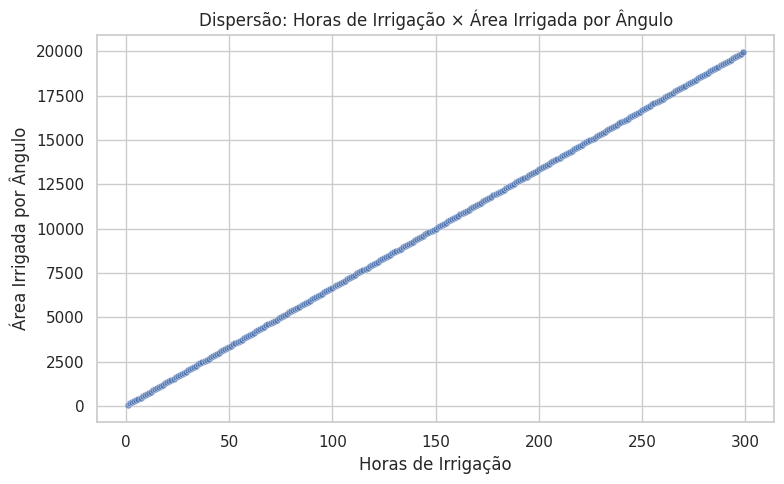

In [ ]:
plt.figure()
sns.scatterplot(data=df, x=X_COL, y=Y_COL, s=25, alpha=0.7)
plt.title(f"Dispersão: {X_COL} × {Y_COL}")
plt.xlabel(X_COL); plt.ylabel(Y_COL)
plt.tight_layout(); plt.show()

## Tarefa 5 — Análise de correlação

Correlação de Pearson mede a força e o sentido da relação **linear** entre pares de
variáveis, de -1 a 1. Valores próximos de 1 indicam que, quando uma cresce, a outra
cresce proporcionalmente — exatamente o que esperamos aqui.

                          Horas de Irrigação  Área Irrigada  \
Horas de Irrigação                       1.0            1.0   
Área Irrigada                            1.0            1.0   
Área Irrigada por Ângulo                 1.0            1.0   

                          Área Irrigada por Ângulo  
Horas de Irrigação                             1.0  
Área Irrigada                                  1.0  
Área Irrigada por Ângulo                       1.0  


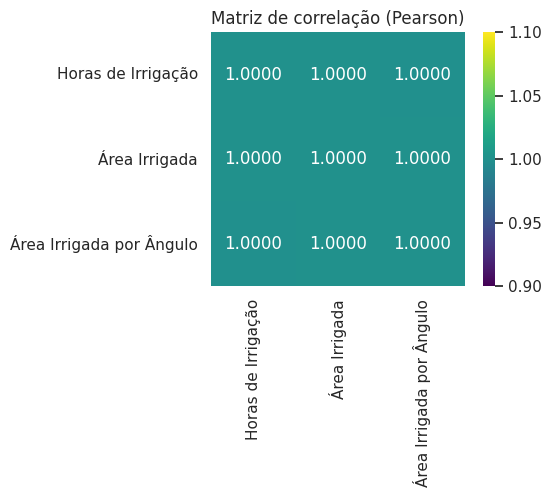

In [ ]:
corr = df.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".4f", cmap="viridis", square=True, cbar=True)
plt.title("Matriz de correlação (Pearson)")
plt.tight_layout(); plt.show()

## Tarefa 6 — Divisão em treino e teste

Separamos os dados para avaliar o modelo em exemplos que ele **não viu** no treino.
Sem isso, mediríamos memorização, não capacidade de generalizar. Usamos 80% treino /
20% teste e `random_state` fixo para reprodutibilidade.

In [ ]:
X = df[[X_COL]]   # 2D: o sklearn espera matriz de features
y = df[Y_COL]     # 1D: alvo

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 239 amostras | Teste: 60 amostras


## Tarefa 7 — Treinar a regressão linear

`X = Horas de Irrigação` (independente), `Y = Área Irrigada por Ângulo` (dependente).
O modelo ajusta a reta `Y = a·X + b` que minimiza o erro quadrático no treino.

In [ ]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)
print("Modelo treinado.")

Modelo treinado.


## Tarefa 8 — Equação da reta

In [ ]:
a = modelo.coef_[0]        # inclinação
b = modelo.intercept_      # intercepto
print(f"Coeficiente angular (a): {a:.6f}")
print(f"Intercepto (b):          {b:.6f}")
print(f"\nEquação: Y = {a:.4f} * X + {b:.4f}")
print(f"Leitura: cada hora extra de irrigação adiciona ~{a:.2f} de área irrigada por ângulo.")

Coeficiente angular (a): 66.666667
Intercepto (b):          0.000000

Equação: Y = 66.6667 * X + 0.0000
Leitura: cada hora extra de irrigação adiciona ~66.67 de área irrigada por ângulo.


## Tarefa 9 — Métricas de desempenho (MSE, MAE)

- **MAE** (erro absoluto médio): erro médio na mesma unidade de Y; fácil de interpretar.
- **MSE** (erro quadrático médio): penaliza erros grandes mais que pequenos (eleva ao quadrado).
- **R²**: fração da variância de Y explicada pelo modelo (1 = ajuste perfeito).

In [ ]:
y_pred = modelo.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"MSE: {mse:.6e}")
print(f"MAE: {mae:.6e}")
print(f"R² : {r2:.6f}")

MSE: 8.248757e-24
MAE: 2.559849e-12
R² : 1.000000


## Tarefa 10 — Resultados reais × preditos

Dois ângulos: (1) reta ajustada sobre todos os pontos; (2) real × predito no teste —
quanto mais perto da diagonal `y = x`, melhor a predição.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


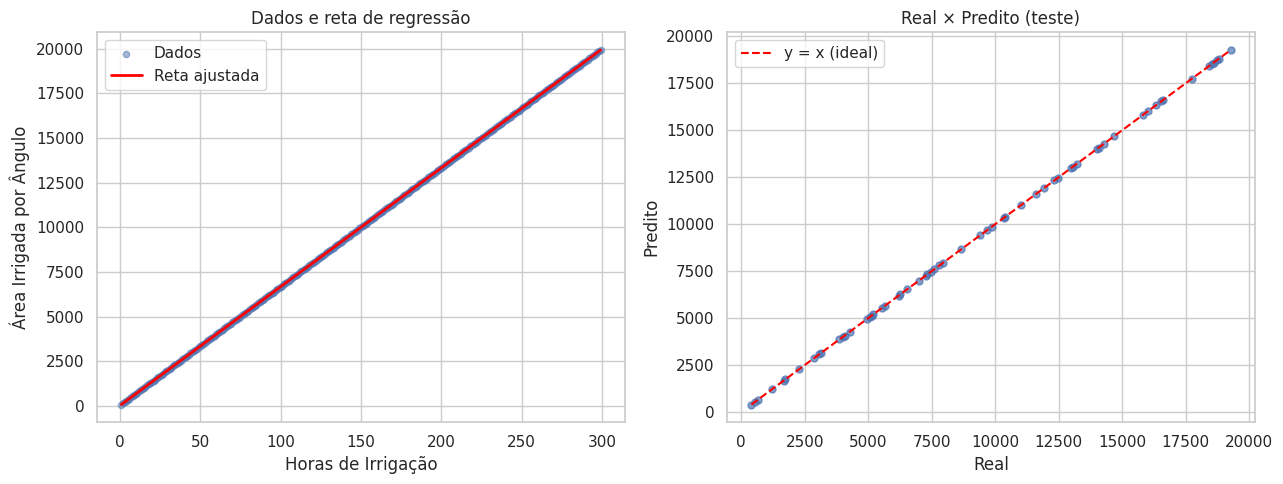

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (1) Reta ajustada sobre os dados
axes[0].scatter(X[X_COL], y, s=20, alpha=0.5, label="Dados")
x_line = np.linspace(X[X_COL].min(), X[X_COL].max(), 100).reshape(-1, 1)
axes[0].plot(x_line, modelo.predict(x_line), color="red", lw=2, label="Reta ajustada")
axes[0].set_title("Dados e reta de regressão")
axes[0].set_xlabel(X_COL); axes[0].set_ylabel(Y_COL); axes[0].legend()

# (2) Real x Predito (conjunto de teste)
axes[1].scatter(y_test, y_pred, s=25, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="red", ls="--", label="y = x (ideal)")
axes[1].set_title("Real × Predito (teste)")
axes[1].set_xlabel("Real"); axes[1].set_ylabel("Predito"); axes[1].legend()

plt.tight_layout(); plt.show()

## Tarefa 11 — Resíduos

Resíduo = valor real − valor predito. A análise busca **padrão**: idealmente os resíduos
se espalham aleatoriamente em torno de zero, sem tendência (que indicaria relação não
capturada pelo modelo linear).

Média dos resíduos:  -2.559849e-12
Desvio-padrão:       1.313269e-12
Mín / Máx:           -7.275958e-12 / 0.000000e+00


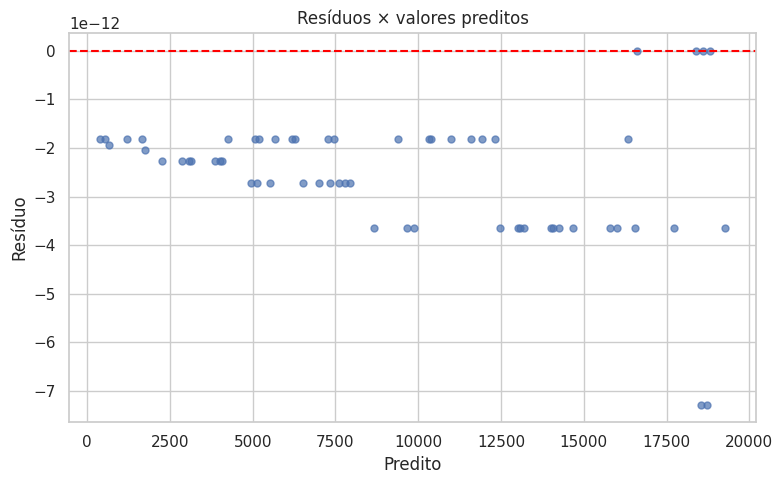

In [ ]:
residuos = y_test - y_pred

print(f"Média dos resíduos:  {residuos.mean():.6e}")
print(f"Desvio-padrão:       {residuos.std():.6e}")
print(f"Mín / Máx:           {residuos.min():.6e} / {residuos.max():.6e}")

plt.figure()
plt.scatter(y_pred, residuos, s=25, alpha=0.7)
plt.axhline(0, color="red", ls="--")
plt.title("Resíduos × valores preditos")
plt.xlabel("Predito"); plt.ylabel("Resíduo")
plt.tight_layout(); plt.show()

> **Observação sobre estes dados:** a relação é exatamente linear e sem ruído
> (`Área Irrigada por Ângulo = 66,6667 × Horas`). Por isso o modelo acerta quase na
> casa decimal: R² ≈ 1, MSE/MAE ≈ 0 e os resíduos ficam na ordem de 1e-11 — apenas
> erro de ponto flutuante, não variação real. Em dados reais, com ruído de medição,
> esses resíduos teriam dispersão de verdade e a análise abaixo passaria a ter peso.

## Tarefa 12 — Normalidade dos resíduos

Por que importa: vários resultados inferenciais da regressão (intervalos de confiança,
testes sobre os coeficientes) assumem resíduos aproximadamente normais. Verificamos com:

- **Histograma** — formato da distribuição.
- **Q-Q plot** — pontos sobre a diagonal indicam normalidade.
- **Shapiro-Wilk** — teste formal; p > 0,05 não rejeita a hipótese de normalidade.

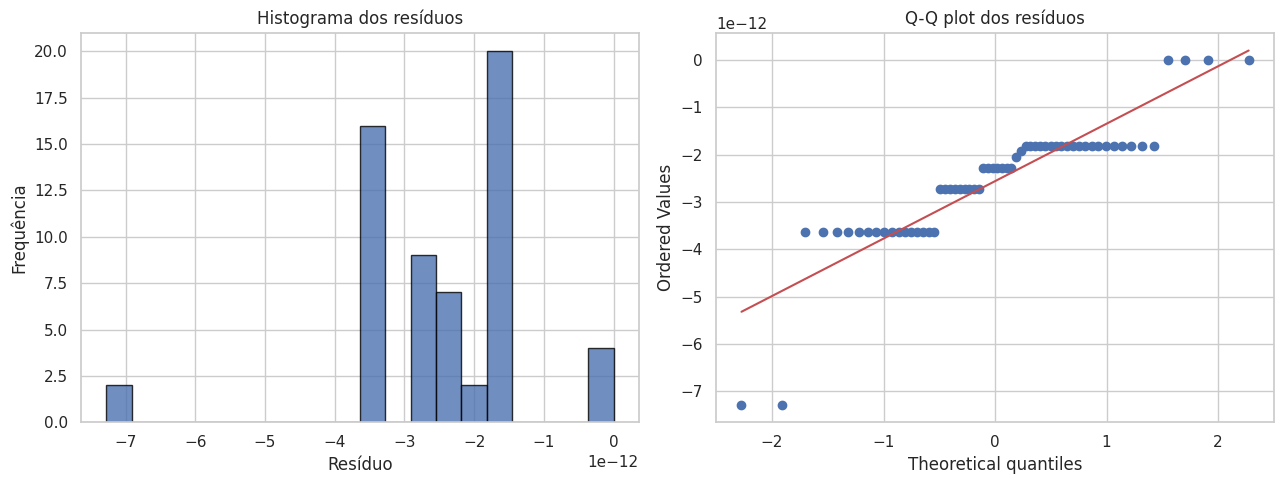

Shapiro-Wilk: W = 0.8258 | p-valor = 6.3048e-07
→ Rejeita normalidade (p ≤ 0,05).

Nota: como os resíduos são ~1e-11 (ruído numérico), este teste é apenas formalidade neste dataset; ele só ganha sentido com resíduos de magnitude real.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma
axes[0].hist(residuos, bins=20, edgecolor="black", alpha=0.8)
axes[0].set_title("Histograma dos resíduos")
axes[0].set_xlabel("Resíduo"); axes[0].set_ylabel("Frequência")

# Q-Q plot
stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot dos resíduos")

plt.tight_layout(); plt.show()

# Teste de Shapiro-Wilk
try:
    W, p = stats.shapiro(residuos)
    print(f"Shapiro-Wilk: W = {W:.4f} | p-valor = {p:.4e}")
    print("→ Não rejeita normalidade (p > 0,05)." if p > 0.05
          else "→ Rejeita normalidade (p ≤ 0,05).")
except Exception as e:
    print("Shapiro-Wilk não pôde ser calculado:", e)

print("\nNota: como os resíduos são ~1e-11 (ruído numérico), este teste é apenas "
      "formalidade neste dataset; ele só ganha sentido com resíduos de magnitude real.")

## Tarefa 13 — Predição: área irrigada por ângulo para 15 horas

In [ ]:
horas = 15
entrada = pd.DataFrame({X_COL: [horas]})
predicao = modelo.predict(entrada)[0]

print(f"Predição para {horas} horas de irrigação: {predicao:.4f}")

# Conferência: como a relação é exata, o valor real para 15h existe nos dados
real = df.loc[df[X_COL] == horas, Y_COL]
if not real.empty:
    print(f"Valor real correspondente nos dados: {real.iloc[0]:.4f}")
    print(f"Diferença: {abs(predicao - real.iloc[0]):.6e}")

Predição para 15 horas de irrigação: 1000.0000
Valor real correspondente nos dados: 1000.0000
Diferença: 1.932676e-12


## Conclusão

O pipeline cobriu carga, exploração, modelagem, avaliação e predição. O modelo
`Y = 66,6667·X + 0` descreve perfeitamente a relação entre horas de irrigação e área
irrigada por ângulo (R² ≈ 1).

**Ressalva honesta:** o desempenho "perfeito" vem do dataset ser determinístico, sem
ruído. Num cenário de produção, dados reais teriam variação, os resíduos passariam a
carregar informação, e as Tarefas 11–12 (análise de resíduos e normalidade) seriam o
que de fato valida se a regressão linear é adequada. Se quiser exercitar essa parte de
forma realista, dá para gerar uma versão dos dados com `Y_ruido = Y + ruído gaussiano`
e repetir o diagnóstico.